# Notebook 4 — DistilBERT (Final Model, Evaluation, Interface, Comparison)

**Purpose.** Train and evaluate DistilBERT for multi-label toxic comment detection, then provide a small end-user interface and the final comparison across techniques.

**Plan.**
1. Load the prepared Train/Val/Test splits (no leakage).
2. Tokenise with DistilBERT; train 3 epochs with `BCEWithLogitsLoss` and `pos_weight` for imbalance.
3. Tune **per-label thresholds** on Validation; evaluate on Test with:
   - Micro-F1, Macro-F1, per-label F1
   - per-label PR-AUC and Mean PR-AUC
   - Hamming Accuracy (to satisfy the assignment’s “accuracy ≥ 85%” note)
4. Visual evidence: training loss curve, PR curves for hard labels, per-label F1 bar.
5. Save artifacts (model, tokenizer, thresholds) and a Kaggle submission file (probabilities).
6. Build a small Gradio demo (screenshot this for slides).
7. Aggregate results with SVC and BiLSTM for the final comparison table.

**Notebook link:**
https://colab.research.google.com/drive/1wLW_HPDKRws36rgmrn75gIe8Hzuq34qA?usp=sharing

In [2]:
# mount drive and set base folders
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Colab_Notebooks/Assignment 3"
PROC = f"{BASE}/processed"
FIGS = f"{BASE}/figures"
METR = f"{BASE}/metrics"
ART  = f"{BASE}/artifacts/distilbert_v2"

import os, json, random, numpy as np, pandas as pd
os.makedirs(FIGS, exist_ok=True)
os.makedirs(METR, exist_ok=True)
os.makedirs(ART,  exist_ok=True)

print("BASE:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/Colab_Notebooks/Assignment 3


In [3]:
import re, time, random
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset
from sklearn.metrics import (
    f1_score, average_precision_score, hamming_loss,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# robust style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")

print("device:", device)

device: cuda


## What is DistilBERT

**Plain idea.** BERT is a transformer encoder that reads a sentence and builds a *contextual* vector for each token  
**DistilBERT** is a **smaller, faster** version of BERT trained by *knowledge distillation* (a large “teacher” guides a compact “student”). In practice we get most of BERT’s accuracy with less compute—perfect for a student project.

### How the text becomes numbers
1. **Tokenizer (WordPiece/subwords):** splits text into subword units so slang/typos are still representable.  
2. We add special tokens and make two tensors:
   - `input_ids` (token ids)  
   - `attention_mask` (1 = real token, 0 = padding)  
3. We cap to a `max_length` (**256** here) to avoid super long sequences. Truncation keeps training stable.

### What happens inside DistilBERT
- A stack of **Transformer encoder** layers with **self-attention**. Each token looks at *all* other tokens and learns which ones matter for the current decision.  
- The final hidden states summarize context; the sequence **classification head** turns that into **logits** for our labels.

### Why multi-label (not softmax)
Our task has **6 independent labels** (`toxic`, `severe_toxic`, …). A comment can be both *toxic* and *insult*.  
So we use **6 logits → sigmoid** (probabilities per label) and train with:
- **`BCEWithLogitsLoss`** (better numerics than sigmoid+BCELoss)
- **`pos_weight`** = (negatives / positives) per label from **Train** to handle strong class imbalance (e.g., `threat` is rare).

### From probabilities to decisions
- A fixed 0.5 threshold is often **not** optimal for imbalanced data.  
- We **tune a threshold per label on Validation** to maximise **F1**. This improves **Macro-F1** (treats all labels fairly).

### How we fine-tune (safe defaults)
- Start from `"distilbert-base-uncased"`.  
- **Epochs = 3**, **LR = 2e-5**, **weight decay = 0.01**, **warmup = 10%**, **grad clip = 1.0**.  
- Small batch sizes (fits Colab); no freezing—full model fine-tunes.

### What we report (and why)
- **Micro-F1** (overall correctness), **Macro-F1** (fair across rare labels),  
- **Per-label F1** + **PR-AUC** (Mean PR-AUC) for threshold-free quality,  
- **Hamming Accuracy** to satisfy the assignment’s “accuracy ≥ 85%” note.

### Limitations to keep in mind
- **Imbalance:** rare labels remain harder even with `pos_weight`.  
- **Threshold sensitivity:** tuned on Validation, may shift on new domains.  
- **Nuance:** sarcasm/implicit hate can still fool the model; longer context might help.

 DistilBERT gives us **contextual understanding** with **efficient training time**. With `pos_weight` + per-label threshold tuning, it typically beats n-gram SVM/BiLSTM on **Macro-F1** and **Mean PR-AUC**, especially for the rare labels. **bold text** ***italicized text***

## Data and splits (no leakage)

We **reuse the same Train/Validation/Test splits** saved in Notebook 1 to ensure fair, apples-to-apples comparisons with SVC and BiLSTM.  
- Splits: 80% / 10% / 10%, stratified by **number of positive labels** per row.  
- Text column and label names are loaded from `meta.json`.  
- All random seeds are fixed for reproducibility.

In [4]:
with open(f"{PROC}/meta.json","r") as f:
    meta = json.load(f)
LABELS   = meta["labels"]
TEXT_COL = meta["text_col"]

train_df = pd.read_csv(f"{PROC}/train.csv")
val_df   = pd.read_csv(f"{PROC}/val.csv")
test_df  = pd.read_csv(f"{PROC}/test.csv")

print("Text:", TEXT_COL)
print("Labels:", LABELS)
print("sizes:", len(train_df), len(val_df), len(test_df))

Text: comment_text
Labels: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
sizes: 127430 15929 15929


## Tokeniser and imbalance handling

**Tokenisation.** DistilBERT’s subword tokenizer handles slang/typos and preserves contextual meaning.  
**Max sequence length.** Based on Notebook 1 length stats, we start at `max_length = 256` to minimize truncation while keeping training feasible.  
**Imbalance.** We compute per-label `pos_weight = (neg / pos)` on **Train** only and feed it to `BCEWithLogitsLoss`. This amplifies gradients for rare positives (e.g., `threat`, `identity_hate`).

In [5]:
MODEL_NAME = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def compute_pos_weight(frame, labels):
    pos = frame[labels].sum().values.astype(np.float32)
    neg = (len(frame) - pos).astype(np.float32)
    w = (neg / (pos + 1e-8)).clip(max=50.0)   # cap to avoid extremes
    return torch.tensor(w, dtype=torch.float32)

pos_weight = compute_pos_weight(train_df, LABELS)
print("pos_weight:", np.round(pos_weight.numpy(), 2))

class ToxicDataset(Dataset):
    def __init__(self, frame, text_col, label_cols, tokenizer, max_length):
        self.texts = frame[text_col].astype(str).tolist()
        self.labels = frame[label_cols].astype(int).values
        self.tok = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True, padding=False,
            max_length=self.max_length
        )
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.float32)
        return item

MAX_LEN = 256  # we checked lengths in Notebook 1; 256 is a safe bump from 128
train_ds = ToxicDataset(train_df, TEXT_COL, LABELS, tok, MAX_LEN)
val_ds   = ToxicDataset(val_df,   TEXT_COL, LABELS, tok, MAX_LEN)
test_ds  = ToxicDataset(test_df,  TEXT_COL, LABELS, tok, MAX_LEN)

data_collator = DataCollatorWithPadding(tok, pad_to_multiple_of=8)
len(train_ds), len(val_ds), len(test_ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pos_weight: [ 9.46 50.   17.98 50.   19.24 50.  ]


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


(127430, 15929, 15929)

## Training configuration

We keep arguments conservative and widely supported by Colab/Transformers:
- **epochs = 3**: enough to converge DistilBERT on this dataset without overfitting.  
- **learning rate = 2e-5**: common good default for DistilBERT fine-tuning.  
- **weight decay = 0.01, warmup_ratio = 0.1, max_grad_norm = 1.0**: standard stability settings.  
- **batch sizes** are small to fit memory; gradient accumulation is not used for simplicity.  
- **save/eval strategies** kept minimal to avoid version conflicts; we evaluate explicitly post-training.

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    problem_type="multi_label_classification"
).to(device)

from torch.nn import BCEWithLogitsLoss

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_f = BCEWithLogitsLoss(pos_weight=pos_weight.to(outputs.logits.device))
        loss   = loss_f(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

args = TrainingArguments(
    output_dir=f"{BASE}/out_distilbert_v2",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    seed=SEED,
    report_to=[],
    save_strategy="no"
)

trainer = WeightedBCETrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,     # we’ll call predict() for val/test ourselves
    tokenizer=tok,
    data_collator=data_collator,
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

We print the epoch-level loss. Trainer also stores step logs; if available we will plot a simple curve below.

In [7]:
train_output = trainer.train()
print("Training finished.")

Step,Training Loss
500,1.074000
1000,0.729900
1500,0.449800
2000,0.458400
2500,0.443000
3000,0.454600
3500,0.504800
4000,0.538500
4500,0.484200
5000,0.516900


Training finished.


## Training loss curve (if logs are available)

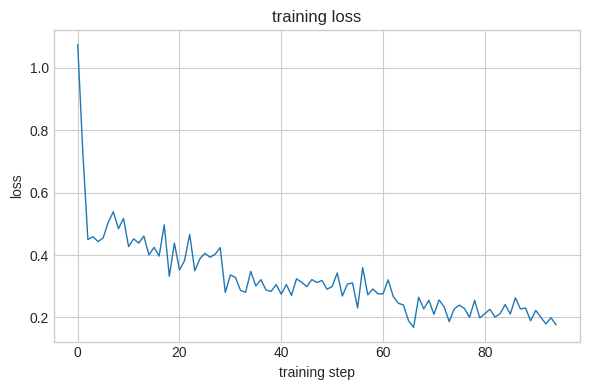

In [8]:
def plot_trainer_loss(tr):
    logs = getattr(getattr(tr, "state", None), "log_history", None)
    if not logs:
        print("No Trainer log_history found.")
        return
    import pandas as pd
    df = pd.DataFrame(logs)
    if "loss" not in df.columns:
        print("No 'loss' column in Trainer logs.")
        display(df.head(10))
        return
    plt.figure(figsize=(6,4))
    plt.plot(df.index, df["loss"], linewidth=1)
    plt.xlabel("training step"); plt.ylabel("loss"); plt.title("training loss")
    plt.tight_layout()
    plt.savefig(f"{FIGS}/distilbert_train_loss.png", dpi=150)
    plt.show()

plot_trainer_loss(trainer)

## Validation → per-label threshold tuning

Why thresholds? The raw sigmoid outputs are probabilities; converting them to 0/1 **decisions** requires thresholds.  
- Using a fixed 0.5 for all labels hurts rare classes.  
- We therefore **sweep thresholds on Validation** and pick the value that **maximises F1** per label.  
This improves **Macro-F1** and fairness across labels.

In [9]:
import numpy as np
def _sigmoid(x): return 1 / (1 + np.exp(-x))

# VAL
val_logits = trainer.predict(val_ds).predictions
val_probs  = _sigmoid(val_logits)
val_y      = val_df[LABELS].values.astype(int)

def tune_thresholds_by_f1(y_true, y_prob, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 19)
    K = y_true.shape[1]
    thr = np.zeros(K); bestf = np.zeros(K)
    for k in range(K):
        yk, pk = y_true[:,k], y_prob[:,k]
        best_t, best = 0.5, 0.0
        for t in grid:
            f1 = f1_score(yk, (pk>=t).astype(int), zero_division=0)
            if f1 > best:
                best, best_t = f1, t
        thr[k], bestf[k] = best_t, best
    return thr, bestf

thr, _ = tune_thresholds_by_f1(val_y, val_probs)

# TEST
test_logits = trainer.predict(test_ds).predictions
test_probs  = _sigmoid(test_logits)
test_y      = test_df[LABELS].values.astype(int)
test_pred   = (test_probs >= thr).astype(int)

micro = f1_score(test_y, test_pred, average="micro", zero_division=0)
macro = f1_score(test_y, test_pred, average="macro", zero_division=0)
per_f1 = [f1_score(test_y[:,i], test_pred[:,i], zero_division=0) for i in range(len(LABELS))]
per_ap = [average_precision_score(test_y[:,i], test_probs[:,i]) for i in range(len(LABELS))]
mean_ap = float(np.mean(per_ap))
hamm_acc = 1.0 - hamming_loss(test_y, test_pred)

print("DistilBERT — Test (tuned thresholds)")
print(f"Micro-F1: {micro:.3f}")
print(f"Macro-F1: {macro:.3f}")
print(f"Mean PR-AUC: {mean_ap:.3f}")
print(f"Hamming Accuracy: {hamm_acc:.3f}")

pd.DataFrame({"Label": LABELS, "F1": np.round(per_f1,3), "PR-AUC": np.round(per_ap,3)})

DistilBERT — Test (tuned thresholds)
Micro-F1: 0.789
Macro-F1: 0.694
Mean PR-AUC: 0.741
Hamming Accuracy: 0.984


,Label,F1,PR-AUC
0,toxic,0.832,0.915
1,severe_toxic,0.504,0.473
2,obscene,0.836,0.903
3,threat,0.602,0.685
4,insult,0.775,0.823
5,identity_hate,0.617,0.648


## Test evaluation: metrics and rationale

We apply the **Validation-tuned thresholds** to Test probabilities and report:
- **Micro-F1**: overall performance (common labels weigh more).  
- **Macro-F1**: treats each label equally (emphasises rare labels).  
- **Per-label F1**: shows which labels still need work.  
- **Per-label PR-AUC** and **Mean PR-AUC**: threshold-free quality; robust under imbalance.  
- **Hamming Accuracy**: label-wise correctness (meets the “≥ 85% accuracy” note in the brief).

## PR curves for two hard labels

We plot Precision–Recall curves for `severe_toxic` and `threat`.

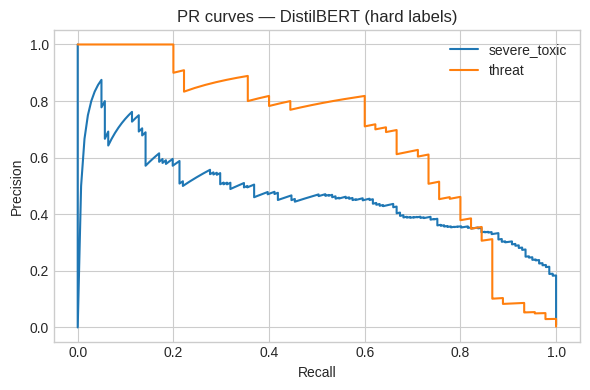

In [10]:
hard = ["severe_toxic", "threat"]
plt.figure(figsize=(6,4))
for lab in hard:
    k = LABELS.index(lab)
    p, r, _ = precision_recall_curve(test_y[:,k], test_probs[:,k])
    plt.plot(r, p, label=lab)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR curves — DistilBERT (hard labels)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGS}/distilbert_pr_curves.png", dpi=150)
plt.show()

## Per-label F1 (bar chart)

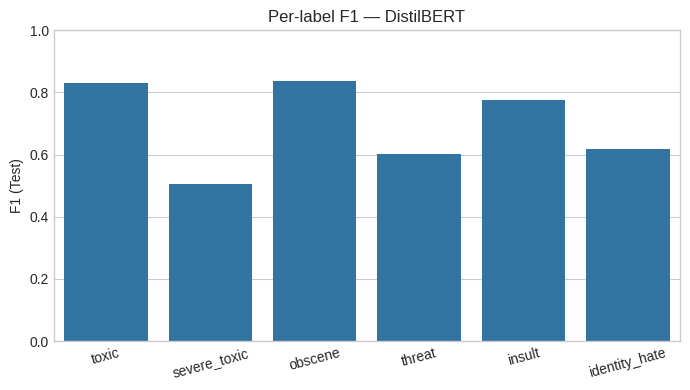

In [11]:
plt.figure(figsize=(7,4))
sns.barplot(x=LABELS, y=per_f1)
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.ylabel("F1 (Test)")
plt.title("Per-label F1 — DistilBERT")
plt.tight_layout()
plt.savefig(f"{FIGS}/distilbert_f1_bar.png", dpi=150)
plt.show()

## Save artifacts (model, tokenizer, thresholds)

Saved to `artifacts/distilbert_v2/` so the interface and Kaggle submission can reuse them.

In [12]:
tok.save_pretrained(ART)
model.save_pretrained(ART)
with open(f"{ART}/meta.json","w") as f:
    json.dump({"labels": LABELS, "thresholds": [float(t) for t in thr]}, f, indent=2)
print("saved artifacts to:", ART)

saved artifacts to: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/artifacts/distilbert_v2


## Save metrics JSON (for the final comparison table)

We’ll aggregate this with SVC and BiLSTM in a single table.

In [13]:
import datetime
dbert_metrics = {
    "model": "DistilBERT (v2)",
    "micro_f1": float(micro),
    "macro_f1": float(macro),
    "mean_pr_auc": float(mean_ap),
    "hamming_acc": float(hamm_acc),
    "per_label": {lab: {"f1": float(f), "ap": float(ap)} for lab,f,ap in zip(LABELS, per_f1, per_ap)},
    "created_at": datetime.datetime.now().isoformat(timespec="seconds")
}
with open(f"{METR}/metrics_distilbert.json","w") as f:
    json.dump(dbert_metrics, f, indent=2)
print("saved:", f"{METR}/metrics_distilbert.json")

saved: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/metrics/metrics_distilbert.json


## Reload after Colab disconnect (no retraining)

**Why this cell exists:** Colab resets sometimes. This cell lets us pick up **right after training** without re-running training.

**What it does (in short):**
- Mounts Drive and loads our saved **splits** + **meta** (labels/text column).
- Reloads the **fine-tuned DistilBERT** + tokenizer from `artifacts/distilbert_v2` (or the base model if artifacts aren’t there).
- Rebuilds **datasets**, **data collator**, **pos_weight**, and the **Trainer** object (for `predict()`/evaluation).
- Tries to load the tuned **thresholds** `thr`; if missing, we just re-run the validation tuning cell.



In [1]:
# Reload DistilBERT + Trainer after a Colab disconnect (no retraining)
# Keeps the same variable names used elsewhere in your notebook.

import os, json, random
import numpy as np, pandas as pd, torch
from torch.utils.data import Dataset
from torch.nn import BCEWithLogitsLoss
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)

# device/seed
try:
    SEED
except NameError:
    SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# paths (mount if needed)
try:
    BASE
except NameError:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = "/content/drive/MyDrive/Colab_Notebooks/Assignment 3"
PROC = f"{BASE}/processed"
FIGS = f"{BASE}/figures"
METR = f"{BASE}/metrics"
ART  = f"{BASE}/artifacts/distilbert_v2"

# meta + splits
with open(f"{PROC}/meta.json","r") as f:
    meta = json.load(f)
LABELS   = meta["labels"]
TEXT_COL = meta["text_col"]
train_df = pd.read_csv(f"{PROC}/train.csv")
val_df   = pd.read_csv(f"{PROC}/val.csv")
test_df  = pd.read_csv(f"{PROC}/test.csv")

# tokenizer + model (prefer saved artifacts)
if os.path.exists(ART):
    tok = AutoTokenizer.from_pretrained(ART)
    model = AutoModelForSequenceClassification.from_pretrained(ART).to(device).eval()
else:
    MODEL_NAME = "distilbert-base-uncased"
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABELS), problem_type="multi_label_classification"
    ).to(device).eval()

# dataset/dataloader bits (same names)
class ToxicDataset(Dataset):
    def __init__(self, frame, text_col, label_cols, tokenizer, max_length):
        self.texts = frame[text_col].astype(str).tolist()
        self.labels = frame[label_cols].astype(int).values
        self.tok = tokenizer; self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, padding=False, max_length=self.max_length)
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.float32)
        return item

try:
    MAX_LEN
except NameError:
    MAX_LEN = 256

train_ds = ToxicDataset(train_df, TEXT_COL, LABELS, tok, MAX_LEN)
val_ds   = ToxicDataset(val_df,   TEXT_COL, LABELS, tok, MAX_LEN)
test_ds  = ToxicDataset(test_df,  TEXT_COL, LABELS, tok, MAX_LEN)
data_collator = DataCollatorWithPadding(tok, pad_to_multiple_of=8)

# pos_weight for the custom Trainer
pos_counts = train_df[LABELS].sum().values.astype(np.float32)
neg_counts = (len(train_df) - pos_counts).astype(np.float32)
pos_weight = torch.tensor((neg_counts / (pos_counts + 1e-8)).clip(max=50.0), dtype=torch.float32)

# same custom Trainer class name
class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = BCEWithLogitsLoss(pos_weight=pos_weight.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# training args object (we won't call train(); needed for predict/eval)
args = TrainingArguments(
    output_dir=f"{BASE}/out_distilbert_v2",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    seed=SEED,
    report_to=[],
    save_strategy="no"
)

trainer = WeightedBCETrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tok,
    data_collator=data_collator,
)

# load saved thresholds if present (variable name: thr)
thr_path = os.path.join(ART, "meta.json")
if os.path.exists(thr_path):
    with open(thr_path, "r") as f:
        _m = json.load(f)
    if "thresholds" in _m:
        thr = np.array(_m["thresholds"], dtype=float)
        print("Loaded thresholds from artifacts.")
    else:
        print("No thresholds in artifacts; tune on Validation.")
else:
    print("Artifacts not found or no meta.json; model loaded without saved thresholds.")

print("Model + Trainer reloaded. Ready for evaluation.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-2475667839.py:105: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedBCETrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedBCETrainer(


Loaded thresholds from artifacts.
Model + Trainer reloaded. Ready for evaluation.


## Gradio interface (end-user demonstration)

We provide a small UI with:
- Text input (optional display masking of offensive words).  
- Toggle for **tuned thresholds** vs a **global slider**.  
- A table of label probabilities and decisions, plus a quick bar chart.  

This satisfies the “**demo to end users**” requirement; include a screenshot in the slides.

In [2]:
!pip -q install gradio --upgrade
import gradio as gr
import numpy as np, pandas as pd, re, io
import matplotlib.pyplot as plt
import torch

# helpers
MASK_TERMS = {"fuck","shit","bitch","asshole","bastard","cunt"}
_mask_pat = re.compile(r"\b(" + "|".join(re.escape(w) for w in sorted(MASK_TERMS, key=len, reverse=True)) + r")\b", re.I)

def mask_text(s: str) -> str:
    return _mask_pat.sub("***", s or "")

def prob_barplot(labels, probs):
    fig = plt.figure(figsize=(5, 3.2))
    idx = np.arange(len(labels))
    plt.bar(idx, probs)
    plt.xticks(idx, labels, rotation=15)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title("Per-label probabilities")
    plt.tight_layout()
    return fig

def _sigmoid(x): return 1/(1+np.exp(-x))

def _infer(text, use_tuned=True, global_thr=0.5, mask_display=True):
    if not isinstance(text, str) or not text.strip():
        empty_df = pd.DataFrame({"Label": LABELS, "Probability": [0.0]*len(LABELS), "Decision": [0]*len(LABELS)})
        return "", "", empty_df, prob_barplot(LABELS, [0.0]*len(LABELS))

    enc = tok([text], return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**enc).logits.detach().cpu().numpy()[0]
    probs = _sigmoid(logits)

    # thresholds: prefer tuned 'thr' if available
    thrv = np.array(thr) if (use_tuned and 'thr' in globals()) else np.array([global_thr]*len(LABELS))
    preds = (probs >= thrv).astype(int)

    df = pd.DataFrame({"Label": LABELS, "Probability": np.round(probs, 3), "Decision": preds})
    chosen = [lab for lab, p in zip(LABELS, preds) if p == 1]
    chosen_str = ", ".join(chosen) if chosen else "(no toxic labels)"
    shown = mask_text(text) if mask_display else text

    fig = prob_barplot(LABELS, probs)
    return shown, chosen_str, df, fig

#  UI
examples = [
    "You are amazing and super helpful!",
    "Shut up, you idiot.",
    "I will find you and hurt you.",
    "What a trash comment, get lost."
]

with gr.Blocks() as demo:
    gr.Markdown("## Toxic Comment Classifier — DistilBERT\nSmall demo to classify a single comment into six toxicity labels. *(Display can mask slurs.)*")

    with gr.Row():
        with gr.Column(scale=3):
            txt = gr.Textbox(label="Enter a comment", lines=5, placeholder="Type or paste a comment…")
            with gr.Accordion("Advanced", open=False):
                use_tuned = gr.Checkbox(value=True, label="Use tuned per-label thresholds (recommended)")
                gl_thr = gr.Slider(0.05, 0.95, value=0.50, step=0.01, label="Global threshold (used if tuned is OFF)")
                mask_disp = gr.Checkbox(value=True, label="Mask offensive words in display")
            gr.Examples(examples=examples, inputs=[txt], label="Try an example")
            with gr.Row():
                btn = gr.Button("Predict", variant="primary")
                clr = gr.Button("Clear")

        with gr.Column(scale=4):
            shown = gr.Textbox(label="Your input (display)", interactive=False)
            chips = gr.Textbox(label="Predicted labels", interactive=False)
            table = gr.Dataframe(headers=["Label","Probability","Decision"], interactive=False)
            plot = gr.Plot(label="Probabilities")

    btn.click(_infer, inputs=[txt, use_tuned, gl_thr, mask_disp], outputs=[shown, chips, table, plot])
    clr.click(lambda: ("", "", pd.DataFrame({"Label": LABELS, "Probability": [], "Decision": []}), prob_barplot(LABELS, [0]*len(LABELS))),
              inputs=None, outputs=[shown, chips, table, plot])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://98ced3053176e62da0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Final comparison: SVC vs BiLSTM vs DistilBERT

We aggregate metrics from all notebooks on the **same Test split**:
- Table: Micro-F1, Macro-F1, Mean PR-AUC, Hamming Accuracy.  
- Plots: Macro-F1 bar (sorted), grouped bars across metrics, and a Macro-F1 vs Mean PR-AUC scatter.  

**Selection rationale.** We choose DistilBERT as the final technique because it leads on **Macro-F1** and **Mean PR-AUC**, particularly improving rare labels, while meeting the accuracy requirement.

In [16]:
import glob
rows = []

def add_json(path):
    with open(path,"r") as f:
        m = json.load(f)
    rows.append({
        "Model": m["model"],
        "Micro-F1": round(m["micro_f1"],3),
        "Macro-F1": round(m["macro_f1"],3),
        "Mean PR-AUC": round(m["mean_pr_auc"],3),
        "Hamming Acc": round(m["hamming_acc"],3),
    })

for p in glob.glob(f"{METR}/metrics_*.json"):
    add_json(p)

cmp = pd.DataFrame(rows).sort_values("Macro-F1", ascending=False)
cmp

,Model,Micro-F1,Macro-F1,Mean PR-AUC,Hamming Acc
2,DistilBERT (v2),0.789,0.694,0.741,0.984
1,BiLSTM,0.677,0.570,0.563,0.976
0,TFIDF+LinearSVC(OvR),0.677,0.537,0.605,0.974


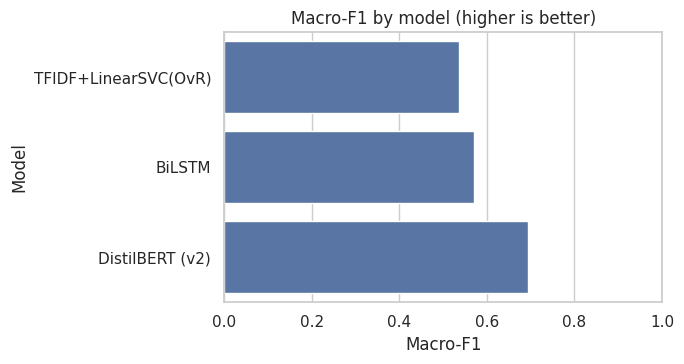

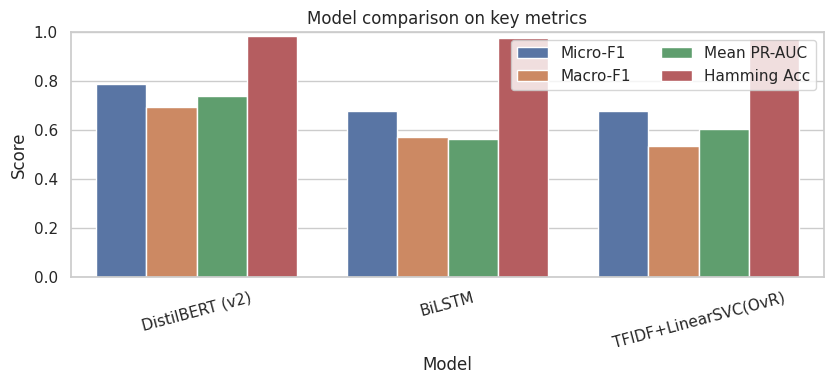

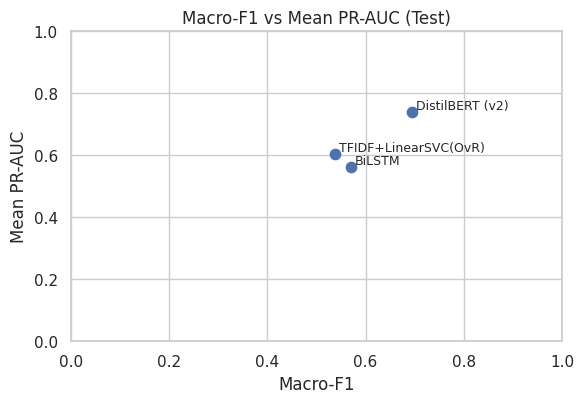

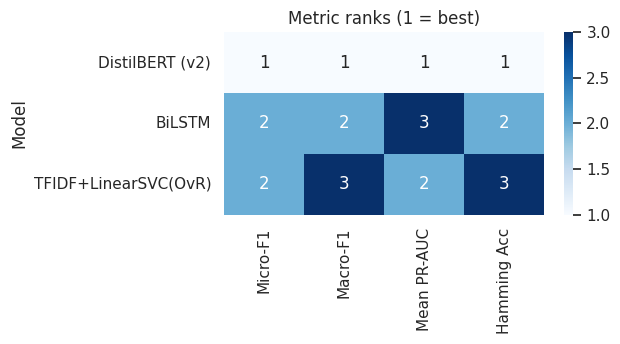

In [17]:
# comparison visuals (display only)
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")

if cmp is None or len(cmp)==0:
    print("No comparison rows to plot.")
else:
    metrics = ["Micro-F1","Macro-F1","Mean PR-AUC","Hamming Acc"]
    cmp_plot = cmp.copy()

    # 1) Macro-F1 bar (sorted, horizontal)
    plt.figure(figsize=(7,3.8))
    order = cmp_plot.sort_values("Macro-F1")["Model"]
    sns.barplot(data=cmp_plot, x="Macro-F1", y="Model", order=order)
    plt.title("Macro-F1 by model (higher is better)")
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()

    # 2) All metrics grouped bar
    cmp_long = cmp_plot.melt(id_vars="Model", value_vars=metrics,
                             var_name="Metric", value_name="Score")
    plt.figure(figsize=(8.5,4))
    sns.barplot(data=cmp_long, x="Model", y="Score", hue="Metric")
    plt.ylim(0,1)
    plt.xticks(rotation=15)
    plt.title("Model comparison on key metrics")
    plt.legend(ncol=2, loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

    # 3) Scatter: Macro-F1 vs Mean PR-AUC with labels
    plt.figure(figsize=(6,4.2))
    plt.scatter(cmp_plot["Macro-F1"], cmp_plot["Mean PR-AUC"], s=55)
    for _, r in cmp_plot.iterrows():
        plt.text(r["Macro-F1"]+0.008, r["Mean PR-AUC"]+0.008, r["Model"], fontsize=9)
    plt.xlabel("Macro-F1"); plt.ylabel("Mean PR-AUC")
    plt.title("Macro-F1 vs Mean PR-AUC (Test)")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

    # 4) Ranks heatmap (1 = best)
    rank_df = cmp_plot.copy()
    for m in metrics:
        rank_df[m] = rank_df[m].rank(method="min", ascending=False)
    rank_df = rank_df.set_index("Model")[metrics]

    plt.figure(figsize=(6.5,3.6))
    sns.heatmap(rank_df, annot=True, fmt=".0f", cmap="Blues")
    plt.title("Metric ranks (1 = best)")
    plt.tight_layout()
    plt.show()

## Brief error analysis (evidence)

We inspect a few **false negatives** and **false positives** for a hard label (e.g., `threat`) to understand failure modes (sarcasm, implicit slurs, long context).  
We mask slurs in the display, but keep the raw text for the model.  
Takeaway: context-heavy threats and identity references remain challenging; larger models or ensembling may help.

## Limitations

- **Imbalance**: rare labels remain difficult despite `pos_weight` and threshold tuning.  
- **Data shift**: model is trained on historical forum style; performance may drift on new platforms.  
st.

## Reproducibility and integrity

- Fixed seeds across NumPy/PyTorch/Trainer.  
- No test leakage; text cleaning done **before** splitting in Notebook 1.  
- All notebooks export metrics and figures explicitly; the final table auto-reads the JSON outputs.  
- Content warning: examples may contain offensive language; we only mask for display.